In [1]:
import torch
import torch.nn as nn
import torch.utils.data as data
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from time import time
import random

# reproducibility
torch.manual_seed(1)
np.random.seed(2)
random.seed(3)

In [ ]:
batch_size = 128

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True,
    transform=torchvision.transforms.ToTensor())

trainloader = data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True,
    transform=torchvision.transforms.ToTensor())

testloader = data.DataLoader(testset, batch_size=16, shuffle=False)

In [70]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder,self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 64),
            nn.Tanh(),
            nn.Linear(64,16),
            nn.Tanh(),
            nn.Linear(16,14)
        )
        self.decoder = nn.Sequential(
            nn.Linear(14,16),
            nn.Tanh(),
            nn.Linear(16,64),
            nn.Tanh(),
            nn.Linear(64,28*28),
            #nn.Unflatten(1,(1,28,28))
        )
    
    def forward(self,x):
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return enc,dec

class AutoEncoder1(nn.Module):
    def __init__(self):
        super(AutoEncoder1,self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 64),
            nn.Tanh(),
            nn.Linear(64,16),
            nn.Tanh(),
            nn.Linear(16,2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2,16),
            nn.Tanh(),
            nn.Linear(16,64),
            nn.Tanh(),
            nn.Linear(64,28*28),
            #nn.Unflatten(1,(1,28,28))
        )
    
    def forward(self,x):
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return enc,dec
    
class CNN_AE(nn.Module):
    def __init__(self):
        super(CNN_AE,self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*26*26, 2),
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 26*26*32),
            nn.ReLU(),
            nn.Unflatten(1, (32, 26, 26)),
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1),
            nn.Tanh()
        )
    
    def forward(self,x):
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return enc,dec

In [62]:
def train_model(model, num_epochs, trainloader, criterion, optimizer):

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    model = model.to(device)

    losses = []
   
    for epoch in range(num_epochs):
        train_running_loss = 0.0

        # Set the model to training mode
        model = model.train()
        start = time()
        ## training step
        for i, (images, labels) in enumerate(trainloader):
            
            # difference here! Similar to .flatten()
            #images = images.view(-1, 28*28)

            images = images.to(device)
            labels = labels.to(device)

            ## forward + backprop + loss
            codes, decoded = model(images)
            loss = criterion(decoded, images)

            # Reset the gradients to zero
            optimizer.zero_grad()

            loss.backward()

            ## update model params
            optimizer.step()

            train_running_loss += loss.item()
        
            
        losses.append(train_running_loss / i)
        
        model.eval()
        print(f"Epoch: {epoch+1} | Loss: {train_running_loss / i:.4f} | Time: {time()-start:.2f}") 
    
    return losses

In [55]:
def show_images(images):
    sqrtn = int(np.ceil(np.sqrt(images.shape[0])))

    for index, image in enumerate(images):
        plt.subplot(sqrtn, sqrtn, index+1)
        plt.imshow(image.reshape(28, 28), cmap='PiYG')
        plt.axis('off')

Epoch: 1 | Loss: 0.0472 | Time: 13.35
Epoch: 2 | Loss: 0.0340 | Time: 12.58
Epoch: 3 | Loss: 0.0317 | Time: 11.37
Epoch: 4 | Loss: 0.0305 | Time: 10.32
Epoch: 5 | Loss: 0.0292 | Time: 10.20
Epoch: 6 | Loss: 0.0274 | Time: 10.27
Epoch: 7 | Loss: 0.0263 | Time: 10.23
Epoch: 8 | Loss: 0.0253 | Time: 11.45
Epoch: 9 | Loss: 0.0246 | Time: 10.49
Epoch: 10 | Loss: 0.0240 | Time: 10.93
Epoch: 11 | Loss: 0.0235 | Time: 11.14
Epoch: 12 | Loss: 0.0232 | Time: 11.08
Epoch: 13 | Loss: 0.0228 | Time: 12.34
Epoch: 14 | Loss: 0.0226 | Time: 11.09
Epoch: 15 | Loss: 0.0224 | Time: 10.47
Epoch: 16 | Loss: 0.0222 | Time: 10.53
Epoch: 17 | Loss: 0.0220 | Time: 10.70
Epoch: 18 | Loss: 0.0219 | Time: 10.55
Epoch: 19 | Loss: 0.0218 | Time: 10.21
Epoch: 20 | Loss: 0.0216 | Time: 14.48
Epoch: 21 | Loss: 0.0215 | Time: 16.89
Epoch: 22 | Loss: 0.0214 | Time: 11.20
Epoch: 23 | Loss: 0.0213 | Time: 10.40
Epoch: 24 | Loss: 0.0212 | Time: 10.56
Epoch: 25 | Loss: 0.0211 | Time: 10.51
Epoch: 26 | Loss: 0.0210 | Time: 1

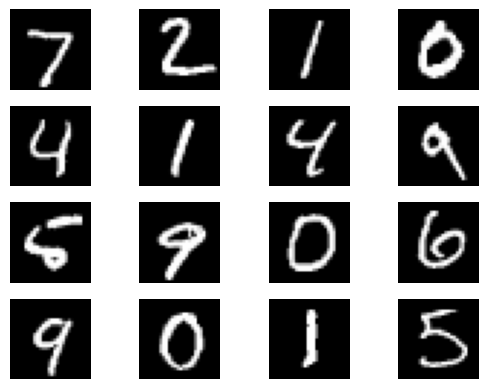

Produced by AutoEncoder


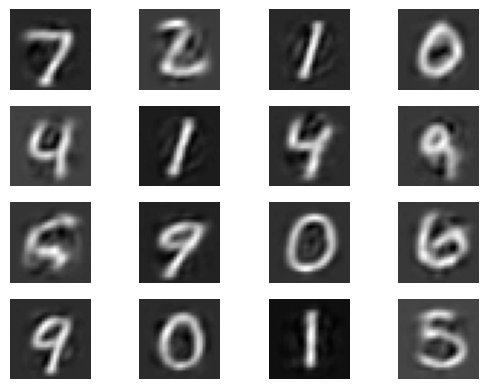

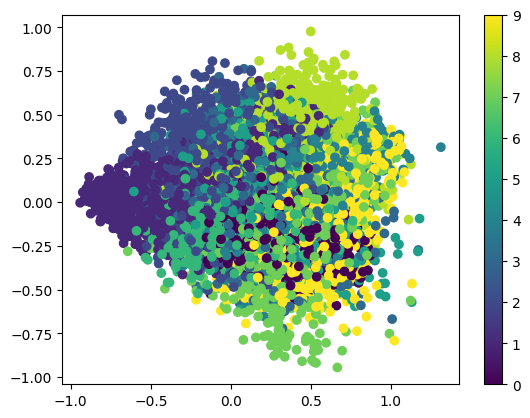

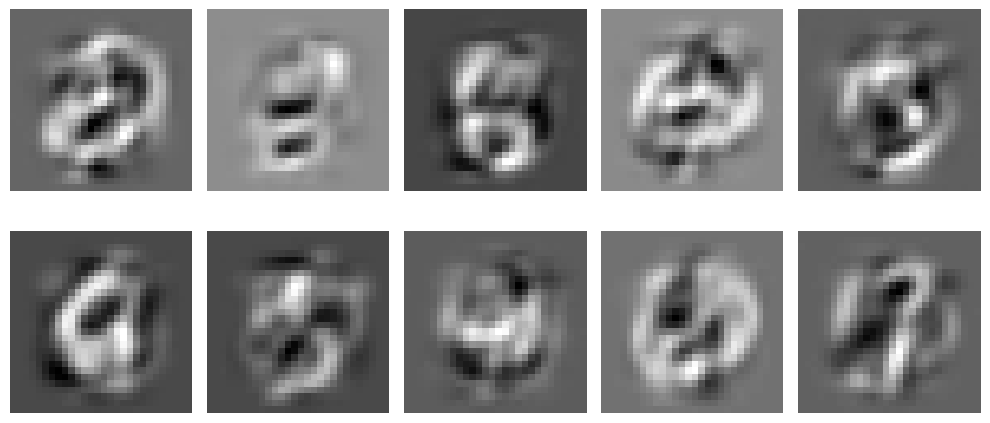

In [54]:
model = AutoEncoder()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
L = train_model(model, 30, trainloader, criterion, optimizer)
model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for images, _ in testloader:
        print("Originals")
        inputs = images.view(-1, 28*28)
        show_images(inputs)
        plt.show()

        print("Produced by AutoEncoder")
        inputs = inputs.to(device)
        code, outputs = model(inputs)
        show_images(outputs.cpu())
        plt.show()
        break

axis_x = []
axis_y = []
answers = []

# turn off gradient calculation to speed up the process
with torch.no_grad():
    for images, labels in testloader:
        inputs = images.view(-1, 28*28)
        answers += labels.tolist()

        inputs = inputs.to(device)
        code, outputs = model(inputs)
        code = code.cpu()
        axis_x += code[:, 0].tolist()
        axis_y += code[:, 1].tolist()


plt.scatter(axis_x, axis_y, c=answers)
plt.colorbar()
plt.show()

model.eval()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
random_latent = torch.normal(mean=-0, std=1, size=(10,14))
reconstructed = model.decoder(random_latent)
images = reconstructed.view(-1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 5)) 
axes = axes.flatten() 
for i in range(10):
    axes[i].imshow(images[i].detach().numpy(), cmap='gray')  
    axes[i].axis('off')
plt.tight_layout()  
plt.show()

Epoch: 1 | Loss: 0.0589 | Time: 12.14
Epoch: 2 | Loss: 0.0514 | Time: 13.14
Epoch: 3 | Loss: 0.0482 | Time: 12.94
Epoch: 4 | Loss: 0.0468 | Time: 12.69
Epoch: 5 | Loss: 0.0460 | Time: 9.90
Epoch: 6 | Loss: 0.0451 | Time: 10.29
Epoch: 7 | Loss: 0.0444 | Time: 12.21
Epoch: 8 | Loss: 0.0438 | Time: 10.15
Epoch: 9 | Loss: 0.0433 | Time: 10.27
Epoch: 10 | Loss: 0.0428 | Time: 11.86
Epoch: 11 | Loss: 0.0425 | Time: 9.93
Epoch: 12 | Loss: 0.0422 | Time: 10.26
Epoch: 13 | Loss: 0.0419 | Time: 11.09
Epoch: 14 | Loss: 0.0416 | Time: 12.50
Epoch: 15 | Loss: 0.0413 | Time: 13.56
Epoch: 16 | Loss: 0.0411 | Time: 11.52
Epoch: 17 | Loss: 0.0409 | Time: 12.34
Epoch: 18 | Loss: 0.0408 | Time: 11.20
Epoch: 19 | Loss: 0.0406 | Time: 12.36
Epoch: 20 | Loss: 0.0405 | Time: 14.04
Epoch: 21 | Loss: 0.0403 | Time: 10.71
Epoch: 22 | Loss: 0.0402 | Time: 9.97
Epoch: 23 | Loss: 0.0401 | Time: 9.70
Epoch: 24 | Loss: 0.0400 | Time: 11.47
Epoch: 25 | Loss: 0.0399 | Time: 12.06
Epoch: 26 | Loss: 0.0398 | Time: 11.49

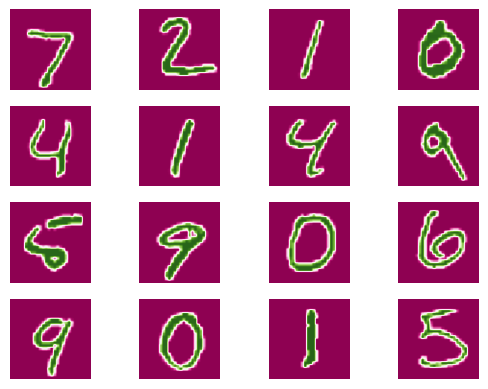

Produced by AutoEncoder


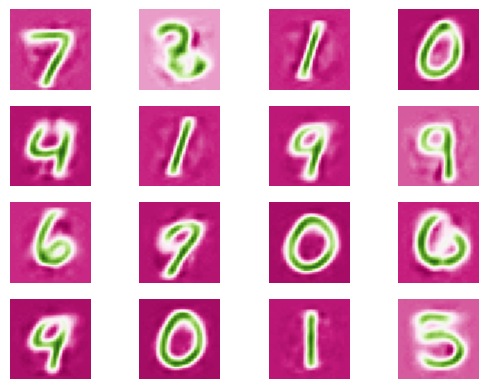

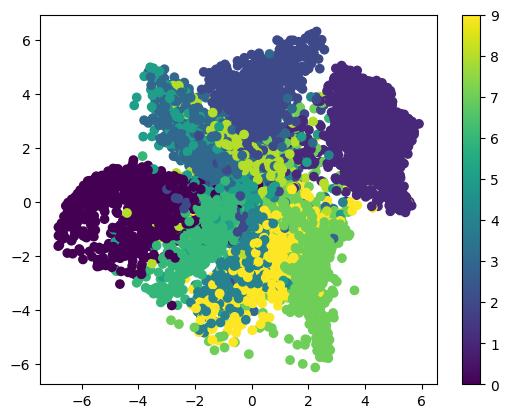

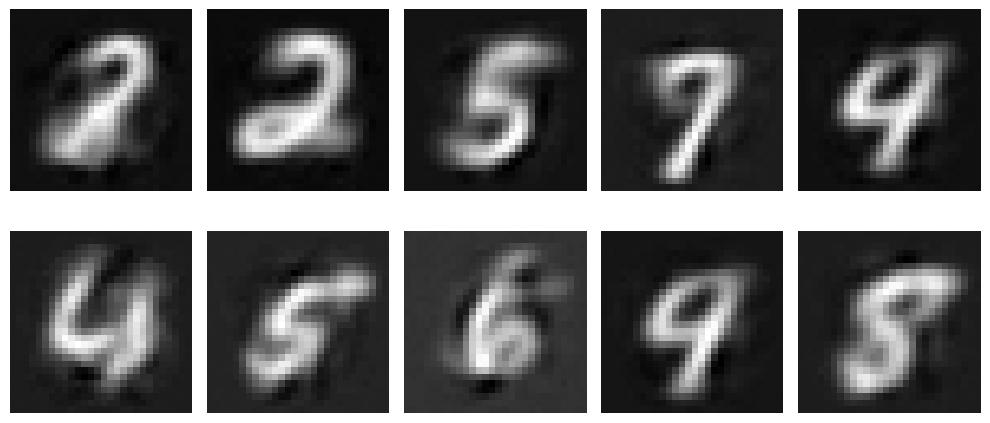

In [60]:
model = AutoEncoder1()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
L = train_model(model, 30, trainloader, criterion, optimizer)
model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for images, _ in testloader:
        print("Originals")
        inputs = images.view(-1, 28*28)
        show_images(inputs)
        plt.show()

        print("Produced by AutoEncoder")
        inputs = inputs.to(device)
        code, outputs = model(inputs)
        show_images(outputs.cpu())
        plt.show()
        break

axis_x = []
axis_y = []
answers = []

# turn off gradient calculation to speed up the process
with torch.no_grad():
    for images, labels in testloader:
        inputs = images.view(-1, 28*28)
        answers += labels.tolist()

        inputs = inputs.to(device)
        code, outputs = model(inputs)
        code = code.cpu()
        axis_x += code[:, 0].tolist()
        axis_y += code[:, 1].tolist()


plt.scatter(axis_x, axis_y, c=answers)
plt.colorbar()
plt.show()

model.eval()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
random_latent = torch.normal(mean=-0, std=1, size=(10,2))
reconstructed = model.decoder(random_latent)
images = reconstructed.view(-1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 5)) 
axes = axes.flatten() 
for i in range(10):
    axes[i].imshow(images[i].detach().numpy(), cmap='gray')  
    axes[i].axis('off')
plt.tight_layout()  
plt.show()

In [71]:
model = CNN_AE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
L = train_model(model, 30, trainloader, criterion, optimizer)
model.eval()



Epoch: 1 | Loss: 0.1246 | Time: 26.43
Epoch: 2 | Loss: 0.0632 | Time: 25.67
Epoch: 3 | Loss: 0.0588 | Time: 25.51
Epoch: 4 | Loss: 0.0557 | Time: 25.80
Epoch: 5 | Loss: 0.0542 | Time: 26.30
Epoch: 6 | Loss: 0.0529 | Time: 26.26
Epoch: 7 | Loss: 0.0518 | Time: 25.54
Epoch: 8 | Loss: 0.0510 | Time: 25.60
Epoch: 9 | Loss: 0.0503 | Time: 25.70
Epoch: 10 | Loss: 0.0496 | Time: 26.78
Epoch: 11 | Loss: 0.0491 | Time: 26.16
Epoch: 12 | Loss: 0.0487 | Time: 25.80
Epoch: 13 | Loss: 0.0483 | Time: 25.89
Epoch: 14 | Loss: 0.0479 | Time: 26.30
Epoch: 15 | Loss: 0.0475 | Time: 25.57
Epoch: 16 | Loss: 0.0471 | Time: 26.05
Epoch: 17 | Loss: 0.0468 | Time: 25.49
Epoch: 18 | Loss: 0.0465 | Time: 25.81
Epoch: 19 | Loss: 0.0463 | Time: 25.67
Epoch: 20 | Loss: 0.0460 | Time: 25.65
Epoch: 21 | Loss: 0.0458 | Time: 25.28
Epoch: 22 | Loss: 0.0457 | Time: 25.65
Epoch: 23 | Loss: 0.0455 | Time: 25.84
Epoch: 24 | Loss: 0.0453 | Time: 25.58
Epoch: 25 | Loss: 0.0452 | Time: 26.00
Epoch: 26 | Loss: 0.0451 | Time: 2

CNN_AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=21632, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=21632, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(32, 26, 26))
    (3): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(1, 1))
    (4): Tanh()
  )
)

Originals


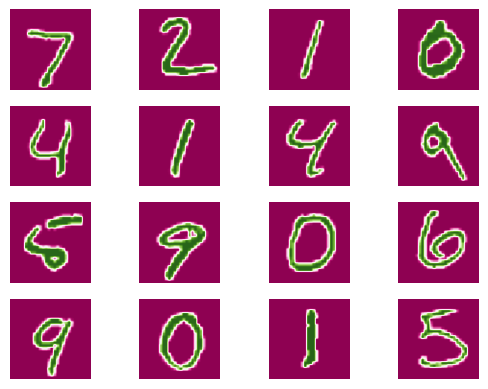

Produced by AutoEncoder


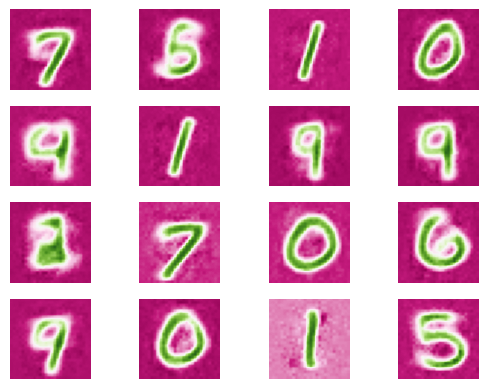

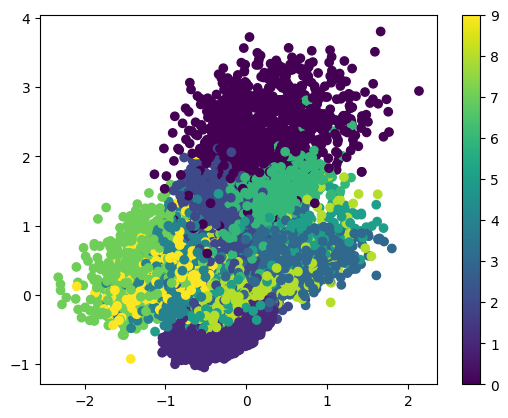

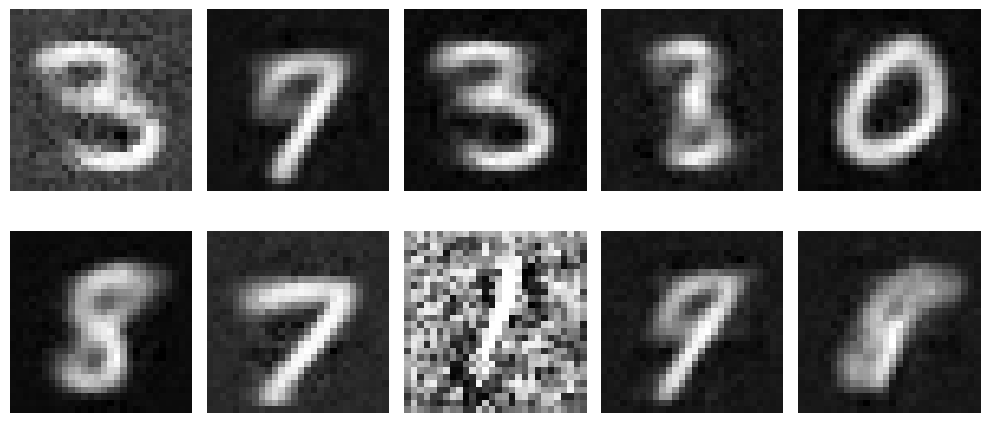

In [75]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for images, _ in testloader:
        print("Originals")
        inputs = images
        show_images(inputs)
        plt.show()

        print("Produced by AutoEncoder")
        inputs = inputs.to(device)
        code, outputs = model(inputs)
        show_images(outputs.cpu())
        plt.show()
        break

axis_x = []
axis_y = []
axis_z = []
answers = []

# turn off gradient calculation to speed up the process
with torch.no_grad():
    for images, labels in testloader:
        inputs = images
        answers += labels.tolist()

        inputs = inputs.to(device)
        code, outputs = model(inputs)
        code = code.cpu()
        axis_x += code[:, 0].tolist()
        axis_y += code[:, 1].tolist()

plt.scatter(axis_x, axis_y, c=answers)
plt.colorbar()
plt.show()

import plotly_express as px

model.eval()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
random_latent = torch.normal(mean=-0, std=1, size=(10,2))
reconstructed = model.decoder(random_latent)
images = reconstructed.view(-1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 5)) 
axes = axes.flatten() 
for i in range(10):
    axes[i].imshow(images[i].detach().numpy(), cmap='gray')  
    axes[i].axis('off')
plt.tight_layout()  
plt.show()

In [69]:
fig = px.scatter_3d(x=axis_x,y = axis_y, z= axis_z, color = answers)
fig.update_traces(marker=dict(size=2, line=dict(width=0)))
fig.show()